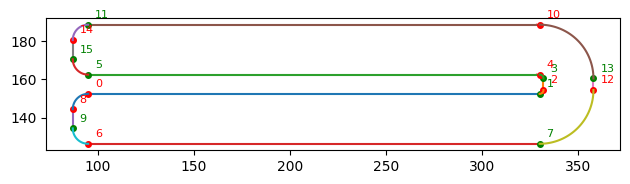

In [ ]:
import ezdxf
import numpy as np
import math
import matplotlib.pyplot as plt

def extract_shapes_points(dxf_file, num_points=50):
    doc = ezdxf.readfile(dxf_file)
    msp = doc.modelspace()
    shapes_data = []

    # 圆
    for circle in msp.query("CIRCLE"):
        center = circle.dxf.center
        radius = circle.dxf.radius
        angles = np.linspace(0, 2*math.pi, num_points, endpoint=False)
        points = [(center.x + radius*math.cos(theta),
                   center.y + radius*math.sin(theta)) for theta in angles]
        points.append(points[0])  # 闭合圆
        shapes_data.append({
            "type": "circle",
            "points": points,
            "center": (center.x, center.y),
            "start_point": points[0],
            "end_point": points[-1]
        })

    # 直线
    for line in msp.query("LINE"):
        start, end = line.dxf.start, line.dxf.end
        xs = np.linspace(start.x, end.x, num_points)
        ys = np.linspace(start.y, end.y, num_points)
        points = list(zip(xs, ys))
        shapes_data.append({
            "type": "line",
            "points": points,
            "start_point": (start.x, start.y),
            "end_point": (end.x, end.y)
        })

    # 折线/矩形
    for pl in msp.query("LWPOLYLINE POLYLINE"):
        vertices = list(pl.get_points("xy"))  # 只取XY坐标
        points = []
        for i in range(len(vertices) - (0 if pl.closed else 1)):
            x1, y1 = vertices[i]
            x2, y2 = vertices[(i+1) % len(vertices)]
            xs = np.linspace(x1, x2, num_points)
            ys = np.linspace(y1, y2, num_points)
            points.extend(list(zip(xs, ys)))
        shapes_data.append({
            "type": "polyline",
            "points": points,
            "vertices": vertices,
            "start_point": vertices[0],
            "end_point": vertices[-1]
        })

    # 圆弧
    for arc in msp.query("ARC"):
        center = arc.dxf.center
        radius = arc.dxf.radius
        start_angle = math.radians(arc.dxf.start_angle)
        end_angle = math.radians(arc.dxf.end_angle)
        span = (end_angle - start_angle) % (2 * math.pi)
        angles = start_angle + np.linspace(0, span, num_points)
        points = [(center.x + radius*math.cos(theta),
                center.y + radius*math.sin(theta)) for theta in angles]
        shapes_data.append({
            "type": "arc",
            "points": points,
            "center": (center.x, center.y),
            "start_point": points[0],
            "end_point": points[-1]
        })

    # 样条曲线
    for spline in msp.query("SPLINE"):
        bspline = spline.construction_tool()
        points = [(p.x, p.y) for p in bspline.approximate(num_points)]
        control_points = [(p[0], p[1]) for p in spline.control_points]
        fit_points = [(p[0], p[1]) for p in spline.fit_points]
        shapes_data.append({
            "type": "spline",
            "points": points,
            "control_points": control_points,
            "fit_points": fit_points,
            "start_point": points[0],
            "end_point": points[-1]
        })

    return shapes_data


import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy

def visualize_shapes(shapes_data):
    fig, ax = plt.subplots()
    point_index = 0
    marked_points = set()  # 已标记点集合

    def mark_point(x, y, color):
        nonlocal point_index
        key = (round(x, 6), round(y, 6))  # 避免浮点误差
        if key not in marked_points:
            # 标记点
            ax.plot(x, y, 'o', color=color, markersize=4)
            # 使用像素偏移，避免数字和点重叠
            text_offset = offset_copy(ax.transData, fig=fig,
                                      x=5, y=5, units='points')
            ax.text(x, y, str(point_index), fontsize=8, color=color,
                    transform=text_offset)
            marked_points.add(key)
            point_index += 1

    for shape in shapes_data:
        xs, ys = zip(*shape["points"])
        ax.plot(xs, ys, '-', label=shape["type"])

        # 起点
        if "start_point" in shape:
            sx, sy = shape["start_point"]
            mark_point(sx, sy, "red")

        # 终点
        if "end_point" in shape:
            ex, ey = shape["end_point"]
            mark_point(ex, ey, "green")

        # # 每个基本形状起点的方向箭头
        # if len(shape["points"]) > 1:
        #     sx, sy = shape["points"][0]
        #     nx, ny = shape["points"][1]
        #     dx, dy = nx - sx, ny - sy
        #     ax.arrow(sx, sy, dx*0.3, dy*0.3,
        #              head_width=0.5, head_length=0.5,
        #              fc='red', ec='red')

    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()







# 示例调用
shapes = extract_shapes_points("../../test/test.dxf", num_points=50)
visualize_shapes(shapes)